# 04 · Algoritmo Integer L-shaped

Este notebook implementa el algoritmo **Integer L-shaped** (Laporte & Louveaux, 1993) para el problema SAA, siguiendo el esquema de la sección 5.2 del enunciado. Se valida contra la formulación extensa del notebook `03_extensive_form.ipynb` sobre la misma muestra de $K=50$ escenarios (sección 5.1).

**Arquitectura (cumple los requisitos mínimos de la sección 5.2):**

- un **maestro como LP por nodo**, con $x_{ij}$ continua en $[lb,ub]$ (las cotas las fija la ramificación de ese nodo), $\theta \ge 0$, restricciones de ruteo relajadas (grado + MTZ), y los cortes globales acumulados;
- evaluación de los $K$ subproblemas de recurso y recuperación de multiplicadores duales;
- cortes estándar de Benders/L-shaped, agregados con peso $1/K$ (vía el promedio en `evaluate_QK`);
- ramificación sobre la variable de arco más cercana a 0.5;
- evaluación exacta del recurso cuando la propuesta es binaria;
- el corte de optimalidad entero con $L=0$;
- selección de nodo por mejor cota, poda por cota/infactibilidad/integralidad, y registro del incumbente.

In [1]:
import time
import json
import heapq
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from pathlib import Path

PROC_DIR = Path("../data/processed")
RESULTS_TABLES = Path("../results/tables")
RESULTS_LOGS = Path("../results/logs")
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_LOGS.mkdir(parents=True, exist_ok=True)

sites = pd.read_csv(PROC_DIR / "sites.csv")
arc_order = pd.read_csv(PROC_DIR / "arc_order.csv")
arc_costs = pd.read_csv(PROC_DIR / "arc_costs.csv")
scenarios = pd.read_parquet(PROC_DIR / "scenarios_K50.parquet")

K = len(scenarios)
V = sites["i"].tolist()
N = [i for i in V if i != 0]
A = list(zip(arc_order["i"], arc_order["j"]))
n = len(N)

c_ij = {(row.i, row.j): row.c_ij for row in arc_costs.itertuples()}

H = 390.0; o_bar = 30.0; c_OT = 1.50; c_EM = 6.00
alpha = {i: 1.0 for i in N}

demand_cost = pd.DataFrame([
    {"i": 1,  "d_i": 30, "c_out_i": 2.60},{"i": 2,  "d_i": 30, "c_out_i": 2.40},
    {"i": 3,  "d_i": 35, "c_out_i": 2.80},{"i": 4,  "d_i": 30, "c_out_i": 2.30},
    {"i": 5,  "d_i": 25, "c_out_i": 2.10},{"i": 6,  "d_i": 25, "c_out_i": 2.00},
    {"i": 7,  "d_i": 35, "c_out_i": 2.70},{"i": 8,  "d_i": 40, "c_out_i": 3.00},
    {"i": 9,  "d_i": 35, "c_out_i": 2.90},{"i": 10, "d_i": 25, "c_out_i": 2.20},
]).set_index("i")
d_i = demand_cost["d_i"].to_dict()
c_out_i = demand_cost["c_out_i"].to_dict()

xi = {s: {(i, j): scenarios.loc[s, f"xi_{i}_{j}"] for (i, j) in A} for s in range(K)}

# Índices de variables del maestro: x_a (a en A), u_i (i en N), theta
n_x = len(A)
n_u = len(N)
idx_x = {a: k for k, a in enumerate(A)}
idx_u = {i: n_x + k for k, i in enumerate(N)}
idx_theta = n_x + n_u

print(f"K = {K} escenarios, |A| = {len(A)} arcos")


K = 50 escenarios, |A| = 110 arcos


## 1. Subproblema de recurso $Q(x, \xi^s)$ y su dual

Para un vector de ruteo fijo $\bar x$ (parámetro, no variable), el subproblema de recurso es:

$$
\begin{aligned}
Q(\bar x, \xi^s) = \min \quad & \sum_{i \in N} c^{out}_i r_i + c^{OT} o + c^{EM} e \\
\text{s.t.} \quad & w_i + r_i = d_i, \quad w_i \in [0, d_i] \\
& \sum_{i \in N} \alpha_i w_i - o - e \le H - \underbrace{\textstyle\sum_{(i,j)\in A} \xi^s_{ij}\bar x_{ij}}_{T(\bar x, \xi^s) \text{ (constante)}} \\
& o \in [0, \bar o], \; e \ge 0
\end{aligned}
$$

Usamos $w_i$ para los minutos ejecutados directamente en segunda etapa (equivalente al $u_i^{(s)}$ del enunciado; ver nota de notación en `03_extensive_form.ipynb`). Esta LP es exacta sea $\bar x$ fraccionaria o binaria, ya que $\bar x$ entra como parámetro fijo, no como variable.

Como $T(\bar x,\xi^s)$ es constante para $\bar x$ fijo, se traslada al lado derecho (RHS). Sea $\pi^s$ el dual de esa restricción. Por sensibilidad de LP:

$$\frac{\partial Q}{\partial \text{RHS}} = \pi^s, \qquad \frac{\partial \text{RHS}}{\partial x_{ij}} = -\xi^s_{ij} \;\Rightarrow\; g^s_{ij} := \frac{\partial Q}{\partial x_{ij}}\bigg|_{\bar x} = -\pi^s \, \xi^s_{ij}$$

Esta subgradiente es válida para **cualquier** $x$ (fraccionario o binario), porque $Q(\cdot,\xi^s)$ es convexa en $x$.

In [2]:
def solve_subproblem(x_fixed: dict, xi_s: dict):
    """Resuelve Q(x_fixed, xi_s) con scipy.optimize.linprog (ver nota de rendimiento arriba).

    Variables en orden: w_1..w_n (trabajo directo por sitio), o, e.
    Retorna (valor óptimo, dual de la restricción de tiempo).
    """
    T_x = sum(xi_s[(i, j)] * x_fixed[(i, j)] for (i, j) in A)
    B = H - T_x

    c = [-c_out_i[i] for i in N] + [c_OT, c_EM]
    A_ub = [[alpha[i] for i in N] + [-1, -1]]
    b_ub = [B]
    bounds = [(0, d_i[i]) for i in N] + [(0, o_bar), (0, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    const = sum(c_out_i[i] * d_i[i] for i in N)
    obj = const + res.fun
    dual = res.ineqlin.marginals[0]
    return obj, dual


def evaluate_QK(x_fixed: dict):
    """Evalúa Q_K(x) = (1/K) sum_s Q(x, xi^s) y el corte agregado asociado.

    Retorna: (QK_val, subgradiente g por arco, término constante del corte)
    """
    Q_vals = np.zeros(K)
    duals = np.zeros(K)
    for s in range(K):
        obj, dual = solve_subproblem(x_fixed, xi[s])
        Q_vals[s] = obj
        duals[s] = dual

    QK_val = Q_vals.mean()

    g = {}
    for (i, j) in A:
        g[(i, j)] = -np.mean([duals[s] * xi[s][(i, j)] for s in range(K)])

    const_term = QK_val - sum(g[(i, j)] * x_fixed[(i, j)] for (i, j) in A)
    return QK_val, g, const_term


## 2. Maestro (LP por nodo)

El maestro contiene:
- las restricciones de ruteo relajadas ($x_{ij}$ continuas en $[lb, ub]$, según la ramificación del nodo);
- las restricciones MTZ de eliminación de subtours (lineales, válidas también con $x$ continua);
- $\theta \ge 0$, que aproxima $Q_K(x)$ desde abajo;
- los **cortes globales acumulados**: tanto los cortes estándar de optimalidad como los cortes enteros, compartidos entre todos los nodos del árbol.

**Corte estándar (Benders):** dado un punto de evaluación $\bar x$,
$$\theta \ge Q_K(\bar x) + \sum_{(i,j)} g_{ij} \,(x_{ij} - \bar x_{ij})$$

**Corte de optimalidad entero** (para cuando $\bar x$ es binaria, con $L=0$ — sección 4, observación importante):
$$\theta \ge (Q_K(\bar x) - L)\Big(\sum_{j \in S^1} x_j - \sum_{j \notin S^1} x_j - |S^1| + 1\Big) + L, \qquad S^1 = \{(i,j) : \bar x_{ij}=1\}$$

**Por qué este corte es seguro incluso con $x$ continua en el maestro:** en cualquier *otro* punto binario factible $\bar x' \ne \bar x$ (otra ruta válida, con la misma cantidad de arcos $|S^1|$), el lado derecho de este corte es siempre $\le L = 0 \le \theta$ — el corte queda automáticamente satisfecho (no-vinculante) en cualquier otra ruta binaria, y al ser una restricción "$\ge$", solo puede *encoger* el politopo del maestro, nunca agrandarlo. Por construcción, **nunca excluye por error una ruta binaria distinta de la que generó el corte**.

**Traducción a la forma de `scipy.linprog` (`A_ub @ x <= b_ub`):** la desigualdad $\theta \ge g\cdot x + c$ se reescribe como $g\cdot x - \theta \le -c$.

In [3]:
def build_and_solve_master(bounds: dict, std_cuts: list, int_cuts: list):
    """Construye y resuelve el maestro LP de un nodo con scipy.optimize.linprog.

    bounds: dict {(i,j): (lb, ub)} con las fijaciones de ramificación de este nodo.
    std_cuts: lista de (g, const) para cortes estándar acumulados globalmente.
    int_cuts: lista de (coeffs, rhs) para cortes enteros acumulados globalmente.
    """
    n_vars = n_x + n_u + 1

    c = np.zeros(n_vars)
    for a in A:
        c[idx_x[a]] = c_ij[a]
    c[idx_theta] = 1.0

    var_bounds = []
    for a in A:
        lb, ub = bounds.get(a, (0, 1))
        var_bounds.append((lb, ub))
    for i in N:
        var_bounds.append((1, n))
    var_bounds.append((0, None))  # theta >= 0

    # Restricciones de grado (igualdades)
    A_eq, b_eq = [], []
    for k in V:
        row = np.zeros(n_vars)
        for (i, j) in A:
            if i == k:
                row[idx_x[(i, j)]] += 1
        A_eq.append(row); b_eq.append(1.0)
        row = np.zeros(n_vars)
        for (i, j) in A:
            if j == k:
                row[idx_x[(i, j)]] += 1
        A_eq.append(row); b_eq.append(1.0)

    # MTZ + cortes (desigualdades)
    A_ub, b_ub = [], []
    for (i, j) in A:
        if i in N and j in N:
            row = np.zeros(n_vars)
            row[idx_u[i]] = 1; row[idx_u[j]] = -1; row[idx_x[(i, j)]] = n
            A_ub.append(row); b_ub.append(n - 1)

    for (g, const) in std_cuts:
        row = np.zeros(n_vars)
        for a in A:
            row[idx_x[a]] = g[a]
        row[idx_theta] = -1
        A_ub.append(row); b_ub.append(-const)

    for (coeffs, rhs) in int_cuts:
        row = np.zeros(n_vars)
        for a in A:
            row[idx_x[a]] = coeffs[a]
        row[idx_theta] = -1
        A_ub.append(row); b_ub.append(-rhs)

    res = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub),
                   A_eq=np.array(A_eq), b_eq=np.array(b_eq),
                   bounds=var_bounds, method="highs")
    if not res.success:
        return None  # infactible -> se poda

    xbar = {a: res.x[idx_x[a]] for a in A}
    theta_val = res.x[idx_theta]
    obj_val = res.fun
    return xbar, theta_val, obj_val


def make_integer_cut(xbar_binary: dict, QK_val: float, L: float = 0.0):
    S1 = [a for a in A if xbar_binary[a] > 0.5]
    coeffs = {a: (QK_val - L) if a in S1 else -(QK_val - L) for a in A}
    rhs = L - (QK_val - L) * (len(S1) - 1)
    return coeffs, rhs


def is_integral(xbar: dict, tol: float = 1e-6) -> bool:
    return all(abs(v - round(v)) < tol for v in xbar.values())


def round_binary(xbar: dict) -> dict:
    return {a: round(v) for a, v in xbar.items()}


## 3. Bucle principal: branch-and-cut

Selección de nodo por **mejor cota** (cola de prioridad sobre la cota LP del nodo padre). Para cada nodo extraído de la cola, hay un **bucle interno** que lo resuelve repetidamente hasta agotarlo por completo:

1. Resolver el maestro con los cortes globales acumulados.
2. Podar por cota o infactibilidad si aplica.
3. **Separación de cortes estándar**: mientras $\theta$ subestime $Q_K(\bar x)$, agregar el corte violado y reoptimizar.
4. Si $\bar x$ es binaria: evaluar exactamente su costo, actualizar incumbente si mejora, agregar el corte entero, y **volver al paso 1 con el mismo nodo**.
5. Si $\bar x$ es fraccionaria: ramificar sobre la variable de arco más cercana a 0.5, empujar los dos hijos a la cola, y pasar al siguiente nodo de la cola.
6. Detener cuando $\text{gap} = \dfrac{UB-LB}{\max\{1,|UB|\}} \le 10^{-3}$.

In [5]:
TOL_CUT = 1e-4
GAP_TOL = 1e-3
MAX_ITERS = 5000
MAX_CUT_SEPARATION_ROUNDS = 30
MAX_SAME_NODE_ROUNDS = 50

t_start = time.time()

std_cuts = []
int_cuts = []
UB = float("inf")
best_x = None
history = []  # (iteración, LB, UB, gap, n_cuts_acumulados)

counter = 0
open_nodes = [(0.0, counter, {})]  # (cota estimada, id_nodo, bounds)
heapq.heapify(open_nodes)

it = 0
gap = float("inf")
PRINT_EVERY = 25  # imprimir progreso cada N iteraciones (para no saturar el output)

while open_nodes and it < MAX_ITERS:
    it += 1
    bound_est, nid, bounds = heapq.heappop(open_nodes)

    if bound_est >= UB - 1e-9:
        continue

    node_exhausted = False
    same_node_round = 0
    while not node_exhausted and same_node_round < MAX_SAME_NODE_ROUNDS:
        same_node_round += 1

        result = build_and_solve_master(bounds, std_cuts, int_cuts)
        if result is None:
            node_exhausted = True
            break
        xbar, theta_val, node_LB = result

        if node_LB >= UB - 1e-9:
            node_exhausted = True
            break

        for _ in range(MAX_CUT_SEPARATION_ROUNDS):
            QK_val, g, const = evaluate_QK(xbar)
            if theta_val < QK_val - TOL_CUT:
                std_cuts.append((g, const))
                result = build_and_solve_master(bounds, std_cuts, int_cuts)
                if result is None:
                    break
                xbar, theta_val, node_LB = result
                if node_LB >= UB - 1e-9:
                    break
            else:
                break

        if result is None or node_LB >= UB - 1e-9:
            node_exhausted = True
            break

        if is_integral(xbar):
            xb = round_binary(xbar)
            QK_val, g, const = evaluate_QK(xb)
            true_cost = sum(c_ij[a] * xb[a] for a in A) + QK_val
            if true_cost < UB - 1e-9:
                UB = true_cost
                best_x = xb
            int_cuts.append(make_integer_cut(xb, QK_val, L=0.0))
        else:
            frac = {a: v for a, v in xbar.items() if abs(v - round(v)) > 1e-6}
            branch_arc = min(frac, key=lambda a: abs(frac[a] - 0.5))
            for fix_val in (0, 1):
                child_bounds = dict(bounds)
                child_bounds[branch_arc] = (fix_val, fix_val)
                counter += 1
                heapq.heappush(open_nodes, (node_LB, counter, child_bounds))
            node_exhausted = True

    LB = min([b for b, _, _ in open_nodes], default=UB)
    gap = (UB - LB) / max(1, abs(UB)) if UB < float("inf") else float("inf")
    history.append((it, LB, UB, gap, len(std_cuts) + len(int_cuts)))

    if it % PRINT_EVERY == 0 or gap <= GAP_TOL:
        elapsed = time.time() - t_start
        print(f"[it {it}] nodos_abiertos={len(open_nodes)}, LB={LB:.4f}, UB={UB:.4f}, "
              f"gap={gap:.6f}, cortes={len(std_cuts)+len(int_cuts)}, t={elapsed:.1f}s")

    if gap <= GAP_TOL:
        print(f"\n¡Convergencia alcanzada en la iteración {it}!")
        break

solve_time = time.time() - t_start
print(f"\n{'='*60}")
print(f"Iteraciones: {it}")
print(f"Tiempo de solución: {solve_time:.2f} s ({solve_time/60:.1f} min)")
print(f"UB final: {UB:.4f}")
print(f"LB final: {LB:.4f}")
print(f"Gap final: {gap:.6f}")
print(f"Cortes estándar: {len(std_cuts)}, cortes enteros: {len(int_cuts)}")
if gap > GAP_TOL:
    print(f"\n⚠️  No se alcanzó la tolerancia de gap ({GAP_TOL}). Considere subir MAX_ITERS.")


[it 25] nodos_abiertos=24, LB=31.8552, UB=inf, gap=inf, cortes=74, t=1.9s
[it 50] nodos_abiertos=45, LB=33.1590, UB=inf, gap=inf, cortes=110, t=3.0s
[it 75] nodos_abiertos=68, LB=34.1632, UB=inf, gap=inf, cortes=148, t=4.3s
[it 100] nodos_abiertos=93, LB=34.7091, UB=inf, gap=inf, cortes=184, t=5.6s
[it 125] nodos_abiertos=114, LB=35.4152, UB=inf, gap=inf, cortes=227, t=7.0s
[it 150] nodos_abiertos=135, LB=36.1175, UB=inf, gap=inf, cortes=264, t=8.4s
[it 175] nodos_abiertos=156, LB=36.9720, UB=inf, gap=inf, cortes=292, t=9.6s
[it 200] nodos_abiertos=177, LB=37.5790, UB=inf, gap=inf, cortes=342, t=11.4s
[it 225] nodos_abiertos=198, LB=38.2486, UB=inf, gap=inf, cortes=388, t=13.2s
[it 250] nodos_abiertos=215, LB=38.8392, UB=inf, gap=inf, cortes=427, t=14.9s
[it 275] nodos_abiertos=230, LB=39.8339, UB=64.8588, gap=0.385837, cortes=471, t=16.7s
[it 300] nodos_abiertos=251, LB=40.1604, UB=64.8588, gap=0.380802, cortes=498, t=18.2s
[it 325] nodos_abiertos=266, LB=40.6540, UB=62.1053, gap=0.34

## 4. Extraer la ruta óptima

In [6]:
assert best_x is not None, "No se encontró ninguna solución entera factible."

selected_arcs = [a for a in A if best_x[a] > 0.5]
next_node = {i: j for (i, j) in selected_arcs}
route = [0]
current = 0
for _ in range(len(V) - 1):
    current = next_node[current]
    route.append(current)
route.append(0)

assert len(set(route[:-1])) == len(V), "La ruta no visita todos los nodos exactamente una vez."

route_names = sites.set_index("i")["name"]
print("Ruta óptima x* (Integer L-shaped):")
print(" -> ".join(route_names[node] for node in route))


Ruta óptima x* (Integer L-shaped):
Javits Center (Depósito) -> Madison Square Garden -> Times Square -> Rockefeller Center -> Grand Central Terminal -> New York Public Library -> Union Square -> Washington Square Park -> South Street Seaport (Pier 17) -> New York Stock Exchange -> One World Trade Center -> Javits Center (Depósito)


## 5. Validación de consistencia contra la forma extensa (sección 5.1)

Se compara el valor objetivo obtenido aquí contra el de `03_extensive_form.ipynb`, sobre la **misma muestra de K=50 escenarios**. Deben coincidir dentro de una tolerancia relativa de $10^{-4}$; las rutas no tienen que ser idénticas si existen empates.

In [7]:
with open(RESULTS_TABLES / "extensive_form_K50_solution.json") as f:
    extensive_result = json.load(f)

extensive_obj = extensive_result["objective"]
lshaped_obj = UB

rel_diff = abs(lshaped_obj - extensive_obj) / max(1, abs(extensive_obj))

print(f"Objetivo forma extensa:    {extensive_obj:.6f}")
print(f"Objetivo Integer L-shaped: {lshaped_obj:.6f}")
print(f"Diferencia relativa: {rel_diff:.8f}")
print(f"¿Dentro de tolerancia 1e-4? {'SÍ' if rel_diff <= 1e-4 else 'NO'}")

assert rel_diff <= 1e-4, "Los valores objetivo no coinciden dentro de la tolerancia exigida."


Objetivo forma extensa:    52.884477
Objetivo Integer L-shaped: 52.884477
Diferencia relativa: 0.00000000
¿Dentro de tolerancia 1e-4? SÍ


## 6. Guardar resultados y traza de convergencia

In [8]:
result = {
    "K": K,
    "objective": UB,
    "LB_final": LB,
    "gap_final": gap,
    "n_iterations": it,
    "n_std_cuts": len(std_cuts),
    "n_int_cuts": len(int_cuts),
    "solve_time_sec": solve_time,
    "route": route,
    "rel_diff_vs_extensive": rel_diff,
}

with open(PROC_DIR / "lshaped_K50_solution.json", "w") as f:
    json.dump(result, f, indent=2)

history_df = pd.DataFrame(history, columns=["iteration", "LB", "UB", "gap", "n_cuts"])
history_df.to_csv(RESULTS_LOGS / "lshaped_convergence_K50.csv", index=False)

print(f"Guardado: {PROC_DIR / 'lshaped_K50_solution.json'}")
print(f"Guardado: {RESULTS_LOGS / 'lshaped_convergence_K50.csv'}")
result


Guardado: ../data/processed/lshaped_K50_solution.json
Guardado: ../results/logs/lshaped_convergence_K50.csv


{'K': 50,
 'objective': np.float64(52.88447673333333),
 'LB_final': 52.844274810000016,
 'gap_final': np.float64(0.0007601838160568214),
 'n_iterations': 2189,
 'n_std_cuts': 2027,
 'n_int_cuts': 5,
 'solve_time_sec': 179.70242500305176,
 'route': [0, 7, 1, 2, 3, 4, 5, 6, 10, 9, 8, 0],
 'rel_diff_vs_extensive': np.float64(2.773338145941297e-10)}

## 7. Vista rápida de la convergencia

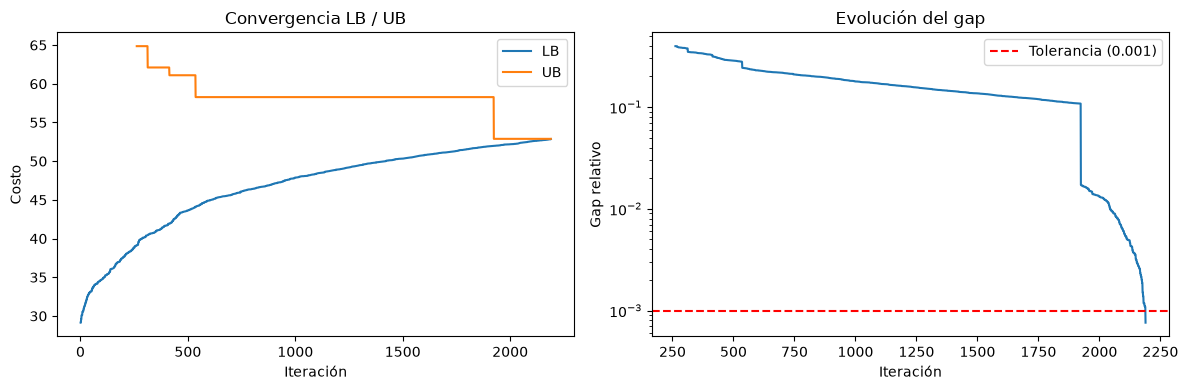

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["iteration"], history_df["LB"], label="LB")
axes[0].plot(history_df["iteration"], history_df["UB"], label="UB")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Costo")
axes[0].set_title("Convergencia LB / UB")
axes[0].legend()

axes[1].plot(history_df["iteration"], history_df["gap"])
axes[1].axhline(GAP_TOL, color="red", linestyle="--", label=f"Tolerancia ({GAP_TOL})")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Gap relativo")
axes[1].set_yscale("log")
axes[1].set_title("Evolución del gap")
axes[1].legend()

plt.tight_layout()
plt.show()
